<a href="https://colab.research.google.com/github/matt-ritton/ts.sugarcane-production/blob/main/Sugarcane_Production.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💻 About this notebook

This academic-oriented notebook was created to analyze historical series of sugarcane production in Brazilian states. The objective is to propose and justify a suitable model for sugarcane production forecasts.

The data were obtained from the SIDRA system of the Brazilian Institute of Geography and Statistics (IBGE).

Data: https://sidra.ibge.gov.br/tabela/6588

### 💬 What will be discussed here?
The notebook is divided into sections based on a time series analysis to solve a production prediction problem. I tried to make it as didactic as possible for understanding.

In [140]:
# Necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

In [2]:
# Upload
from google.colab import files
uploaded = files.upload()

Saving CANA.csv to CANA.csv


In [136]:
# Seaborn theme
sns.set_theme(
    style="whitegrid",
    context="notebook"
)

In [8]:
df = pd.read_csv('SUGARCANE.csv', sep=",", skiprows=5, header=None, encoding='utf-8-sig')

# ------------------------------------------------------------
# Data preparation
# ------------------------------------------------------------

# Define columns names (month + states)
states = [
    'RO', 'AC', 'AM', 'RR', 'PA', 'AP', 'TO',
    'MA', 'PI', 'CE', 'RN', 'PB', 'PE',
    'AL', 'SE', 'BA', 'MG', 'ES', 'RJ',
    'SP', 'PR', 'SC', 'RS',
    'MS', 'MT', 'GO', 'DF'
]
df.columns = ['Month'] + states

# Keep only valid monthly observations
## Some rows may contain notes, totals, or other non-data content.
df = df[df['Month'].str.match(r'^[a-záéíóúâêîôûãõç]+ \d{4}$', na=False)]

# Convert missing values and numerical columns
df[states] = df[states].replace('-', pd.NA)
df[states] = df[states].apply(pd.to_numeric, errors='coerce')

# Convert Portuguese month names into dates
months_pt = {
    'janeiro': '01', 'fevereiro': '02', 'março': '03', 'abril': '04',
    'maio': '05', 'junho': '06', 'julho': '07', 'agosto': '08',
    'setembro': '09', 'outubro': '10', 'novembro': '11', 'dezembro': '12'
}

# String to pandas Timestamp
def parse_month(s):
    s = s.strip().lower()
    for name, num in months_pt.items():
        if s.startswith(name):
            year = s.split()[-1]
            return pd.Timestamp(f"{year}-{num}-01")
    return pd.NaT
df['Date'] = df['Month'].apply(parse_month)

# ------------------------------------------------------------
# Inspect the data
# ------------------------------------------------------------

# Set the date as the dataset index
df = df.drop(columns='Month').set_index('Date').sort_index()

serie = df.index

## 🔍 Exploratory Time Series Analysis

Lorem Ipsum

In [80]:
# Filter by state
state_filter = 'MG'
state_series = df[state_filter].astype(float)

In [79]:
# ------------------------------------------------------------
# Time Series Info
# ------------------------------------------------------------

print(f"Selected state: {state_filter}")
print(f"Initial date: {state_series.index.min().strftime('%Y-%m')}")
print(f"Final date: {state_series.index.max().strftime('%Y-%m')}")
print(f"Number of observations: {state_series.shape[0]}")
print(f"Number of missing values: {state_series.isna().sum()}")

Selected state: MG
Initial date: 2006-09
Final date: 2026-03
Number of observations: 235
Number of missing values: 0


In [89]:
# ------------------------------------------------------------
# Descriptive Statistics
# ------------------------------------------------------------

summary_statistics = pd.DataFrame({
    "Mean": [state_series.mean()],
    "Median": [state_series.median()],
    "Standard deviation": [state_series.std()],
    "Minimum": [state_series.min()],
    "Maximum": [state_series.max()],
    "Missing values": [state_series.isna().sum()]
})

summary_statistics

,Mean,Median,Standard deviation,Minimum,Maximum,Missing values
0,6.842637e+07,70965123.0,1.280182e+07,30004140.0,86735424.0,0


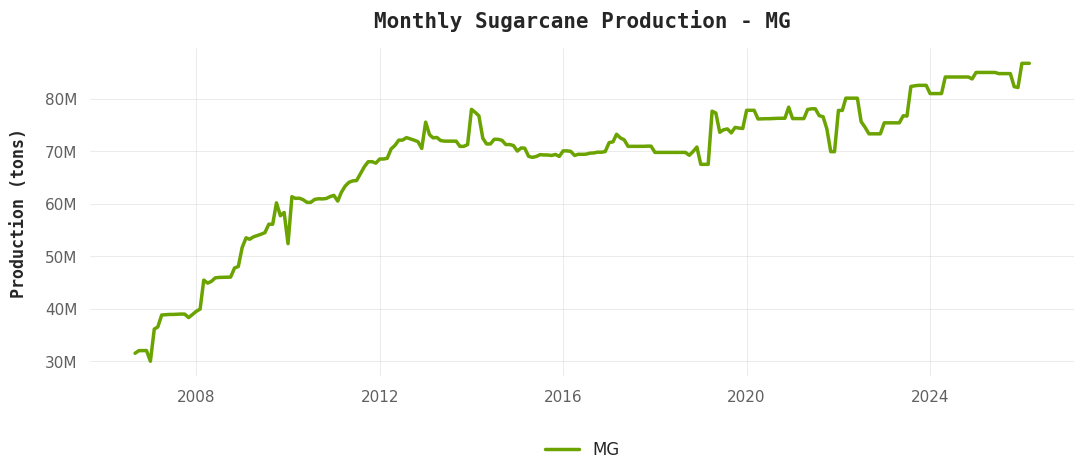

In [139]:
# ------------------------------------------------------------
# Time Series Visualization
# ------------------------------------------------------------

# Plotting
fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(x=state_series.index, y=state_series.values, ax=ax, linewidth=2.5, label=f'{state_filter}', color="#6BA300")
ax.set_title(f"Monthly Sugarcane Production - {state_filter}", fontsize=15, fontweight="semibold", fontfamily="monospace", pad=15)

ax.set_xlabel("", fontsize=12)
ax.tick_params(axis='x', which="both", colors="#606060")

ax.set_ylabel("Production (tons)", fontsize=12, fontweight="semibold", fontfamily="monospace", labelpad=12)
ax.tick_params(axis='y', which="both", colors="#606060")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

## Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=1, frameon=False, fontsize=12)
ax.grid( True, which="major", linestyle="-", linewidth=0.7, alpha=0.4)

plt.tight_layout()
plt.show()

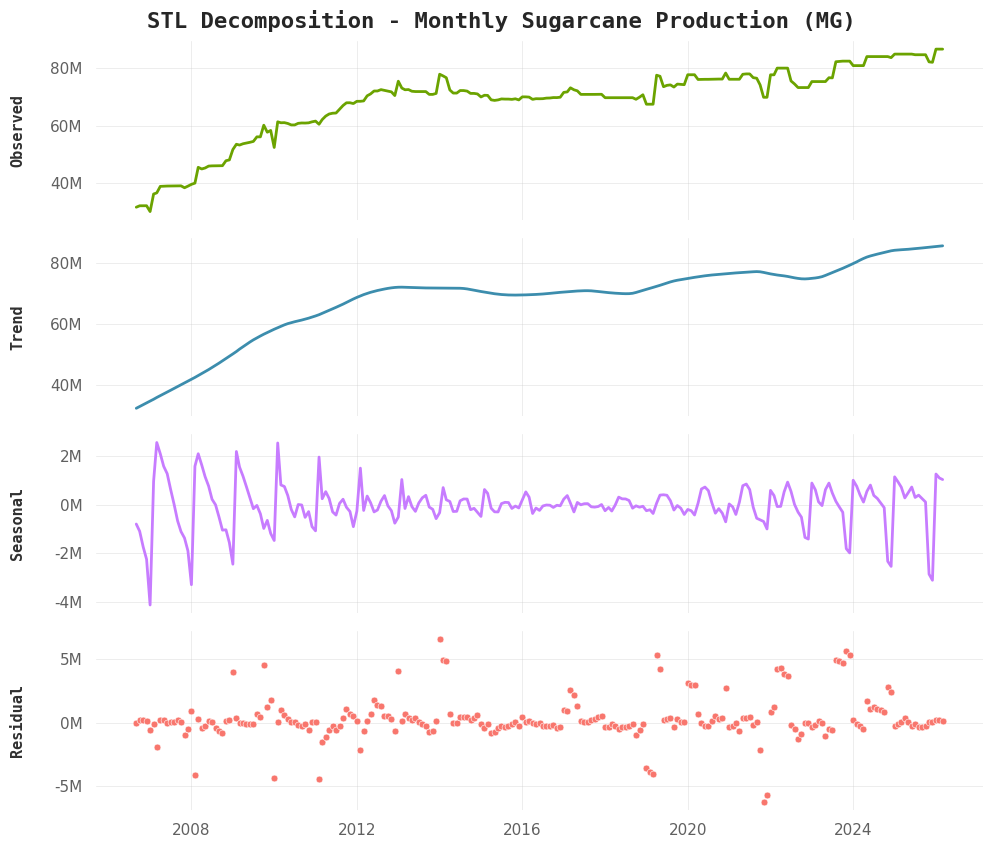

In [153]:
# ------------------------------------------------------------
# Time Series Decomposition
# ------------------------------------------------------------
stl = STL(state_series, period=12, robust=True)
res = stl.fit()

# Plotting decomposition
observed = state_series
trend = res.trend
seasonal = res.seasonal
residual = res.resid

fig, axes = plt.subplots(4, 1,figsize=(10, 9),sharex=True)

component_data = [
    (observed, "Observed", "#6BA300"),
    (trend, "Trend", "#3C8DAD"),
    (seasonal, "Seasonal", "#C77CFF"),
    (residual, "Residual", "#F8766D")
]

for ax, (series, label, color) in zip(axes, component_data):

    if label == "Residual":
      sns.scatterplot(x=series.index, y=series.values, ax=ax, color=color, s=24)
    else:
      sns.lineplot(x=series.index, y=series.values, ax=ax, linewidth=2.0, color=color)

    fig.suptitle(f"STL Decomposition - Monthly Sugarcane Production ({state_filter})", fontsize=16, fontweight="semibold", fontfamily="monospace", y=0.94)

    ax.set_ylabel(label, fontsize=11, fontweight="semibold", fontfamily="monospace", color="#303030")
    ax.yaxis.set_label_coords(-0.08, 0.5)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

    ax.grid(True, which="major", linestyle="-", linewidth=0.7, alpha=0.35)

    ax.tick_params(axis="x", which="both", colors="#606060")
    ax.tick_params(axis="y", which="both", colors="#606060")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

## Hide x label in upper panels
for ax in axes[:-1]:
    ax.set_xlabel("")

axes[-1].set_xlabel("", fontsize=12, fontweight="semibold", fontfamily="monospace", color="#303030")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 📈 Stationarity Analysis

Lorem ipsum

In [145]:
# ------------------------------------------------------------
# Augmented Dickey-Fuller Test
# ------------------------------------------------------------
adf_result = adfuller(state_series.dropna())

adf_output = pd.Series(
    {
        "ADF statistic": adf_result[0],
        "p-value": adf_result[1],
        "Number of lags used": adf_result[2],
        "Number of observations": adf_result[3],
        "Critical value 1%": adf_result[4]["1%"],
        "Critical value 5%": adf_result[4]["5%"],
        "Critical value 10%": adf_result[4]["10%"]
    }
)

adf_output

,0
ADF statistic,-3.336003
p-value,0.013344
Number of lags used,6.000000
Number of observations,228.000000
Critical value 1%,-3.459361
Critical value 5%,-2.874302
Critical value 10%,-2.573571


In [ ]:
# Difference (if necessary)
# serie_diff = state_series.diff().dropna()

### Preliminary Conclusion on Stationarity

Lorem ipsum

## 🔗 Autocorrelation Analysis

Lorem ipsum

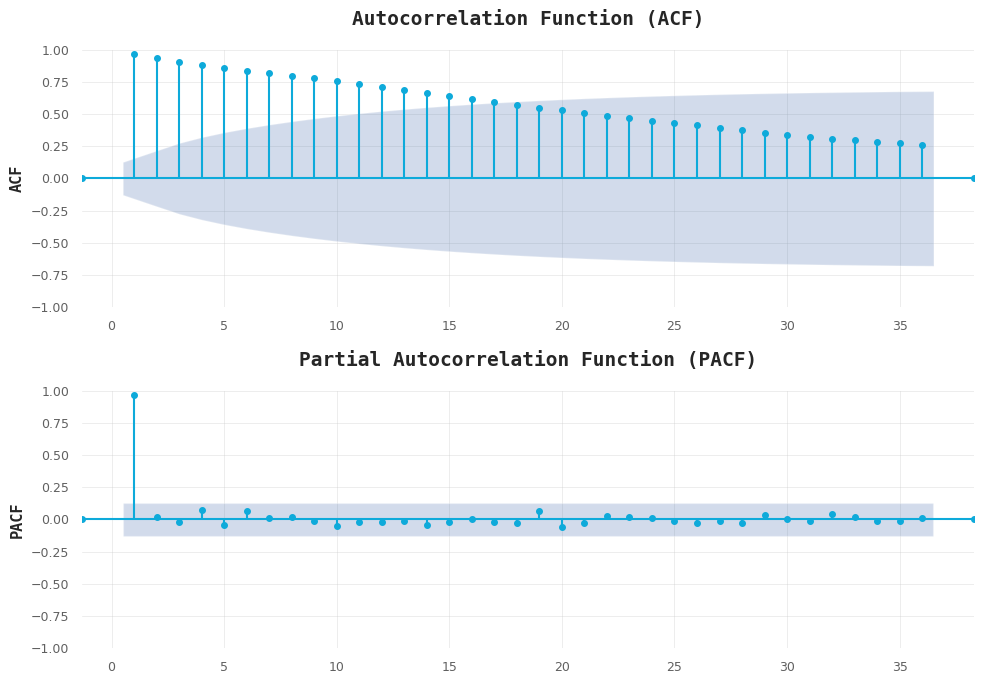

In [159]:
# ------------------------------------------------------------
# Plot ACF and PACF
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(10, 7))

plot_acf(state_series, lags=36, ax=axes[0], alpha=0.05, zero=False, title="", marker="o", markersize=4, color="#0EAADA", vlines_kwargs={"colors": "#0EAADA", "linewidth": 1.5})
plot_pacf(state_series, lags=36, ax=axes[1], alpha=0.05, zero=False, method="ywm", title="", marker="o", markersize=4, color="#0EAADA", vlines_kwargs={"colors": "#0EAADA", "linewidth": 1.5})

axes[0].set_title("Autocorrelation Function (ACF)", fontsize=14, fontweight="semibold", fontfamily="monospace", pad=18)
axes[0].set_ylabel("ACF", fontsize=11, fontweight="semibold", fontfamily="monospace")

axes[1].set_title("Partial Autocorrelation Function (PACF)", fontsize=14, fontweight="semibold", fontfamily="monospace", pad=18)
axes[1].set_ylabel("PACF", fontsize=11, fontweight="semibold", fontfamily="monospace")

for ax in axes:
    ax.tick_params(axis="x", which="both", colors="#606060", labelsize=9)
    ax.tick_params(axis="y", which="both", colors="#606060", labelsize=9)

    ax.grid(True, which="major", linestyle="-", linewidth=0.7, alpha=0.35)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

plt.tight_layout()
plt.show()

### Autocorrelation and Partial Autocorrelation Analysis

Lorem ipsum

## 🧪 Forecasting Experimental Setup

Lorem ipsum

## 👀 Forecasting Models

Lorem ipsum